# 📝 Campaign Viability Analyzer — Text Pipeline Notebook
### Notebook 02: TF-IDF Vectorization of Campaign Names

---

**Author:** Aarsh Bhatnagar  
**Input:** `data/kickstarter_clean.csv` (output of Notebook 01)  
**Outputs:** `artifacts/tfidf.pkl` · `artifacts/X_train_tfidf.npz` · `artifacts/X_test_tfidf.npz`  
           `artifacts/y_train.npy` · `artifacts/y_test.npy` · `artifacts/train_idx.npy` · `artifacts/test_idx.npy`

---

> **How to read this notebook:**  
> Every code cell is preceded by a markdown cell explaining **What**, **Why**, and **What to look for**.  
> This notebook converts raw campaign titles into numerical TF-IDF feature matrices,  
> and creates the permanent train/test split used by all subsequent notebooks.


---
## Section 0 — Imports & Configuration

**What:** Load all required libraries and define every parameter in one place.  
**Why:** Same rule as Notebook 01 — one CONFIG cell, never hardcode values inside the code.  
If you want to change TF-IDF features from 2500 to 5000, you change it here only.  
**Rule:** This notebook never touches the raw CSVs. It only reads from `data/kickstarter_clean.csv`.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import re
import os
import joblib
import scipy.sparse
import warnings

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from collections import Counter

warnings.filterwarnings('ignore')

# ── Visual style ──────────────────────────────────────────────────────────────
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid', palette='muted')

# ── Configuration ─────────────────────────────────────────────────────────────
CONFIG = {
    # Input
    'clean_data_path' : 'data/kickstarter_clean.csv',

    # Text column
    'text_col'           : 'name',
    'target_col'         : 'target',

    # TF-IDF parameters
    'tfidf_max_features' : 2500,   # Keep top 2500 words by TF-IDF score
    'tfidf_min_df'       : 2,      # Ignore words appearing in < 2 documents
    'tfidf_max_df'       : 0.95,   # Ignore words appearing in > 95% of documents
    'tfidf_ngram_range'  : (1, 2), # Use unigrams AND bigrams
    'tfidf_sublinear_tf' : True,   # Apply log normalization to term frequencies

    # Train/test split — set ONCE here, used across ALL notebooks
    'test_size'          : 0.20,
    'random_state'       : 42,

    # Output paths
    'artifacts_dir'   : 'artifacts/',
    'plots_dir'       : 'plots/',
}

# ── Create output directories ─────────────────────────────────────────────────
os.makedirs(CONFIG['artifacts_dir'], exist_ok=True)
os.makedirs(CONFIG['plots_dir'],     exist_ok=True)

print("✅ Libraries loaded")
print(f"   Input file         : {CONFIG['clean_data_path']}")
print(f"   TF-IDF features    : {CONFIG['tfidf_max_features']}")
print(f"   N-gram range       : {CONFIG['tfidf_ngram_range']}  (unigrams + bigrams)")
print(f"   Min doc frequency  : {CONFIG['tfidf_min_df']}  (ignore very rare words)")
print(f"   Max doc frequency  : {CONFIG['tfidf_max_df']}  (ignore very common words)")
print(f"   Sublinear TF       : {CONFIG['tfidf_sublinear_tf']}  (log normalization)")
print(f"   Test split size    : {CONFIG['test_size']}")
print(f"   Artifacts dir      : {CONFIG['artifacts_dir']}")
print("✅ Output directories ready")


✅ Libraries loaded
   Input file         : data/kickstarter_clean.csv
   TF-IDF features    : 2500
   N-gram range       : (1, 2)  (unigrams + bigrams)
   Min doc frequency  : 2  (ignore very rare words)
   Max doc frequency  : 0.95  (ignore very common words)
   Sublinear TF       : True  (log normalization)
   Test split size    : 0.2
   Artifacts dir      : artifacts/
✅ Output directories ready


---
## Section 1 — Load Clean Dataset

**What:** Load the output of Notebook 01 from `data/kickstarter_clean.csv`.  
**Why:** We never touch the raw CSVs again. All downstream notebooks load from this single clean file.  
**What to look for:** Shape should be `331,583 rows × 14 columns`. Target balance ~40/60.


In [2]:
df = pd.read_csv(CONFIG['clean_data_path'])

print(f"  Shape   : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"  Columns : {df.columns.tolist()}")
print(f"\n  Target distribution:")
print(f"    Successful (1) : {df['target'].sum():,}  ({df['target'].mean():.1%})")
print(f"    Failed     (0) : {(1-df['target']).sum():,}  ({1-df['target'].mean():.1%})")

# Verify text column
null_names  = df[CONFIG['text_col']].isnull().sum()
empty_names = (df[CONFIG['text_col']] == '').sum()
print(f"\n  Text column ({CONFIG['text_col']}):")
print(f"    Null values  : {null_names}")
print(f"    Empty strings: {empty_names}")

# Fill any remaining nulls
df[CONFIG['text_col']] = df[CONFIG['text_col']].fillna('')
print("\n  ✅ Dataset loaded successfully")


  Shape   : 331,583 rows × 14 columns
  Columns : ['name', 'category', 'main_category', 'currency', 'deadline', 'launched', 'country', 'usd_goal_real', 'target', 'campaign_duration_days', 'name_length', 'launch_month', 'launch_day_of_week', 'launch_year']

  Target distribution:
    Successful (1) : 133,921  (40.4%)
    Failed     (0) : 197,662  (59.6%)

  Text column (name):
    Null values  : 3
    Empty strings: 0

  ✅ Dataset loaded successfully


---
## Section 2 — Train / Test Split

**What:** Split the dataset into training (80%) and testing (20%) sets.  
**Why:** This is the most important structural decision in the entire project.  

We split **here, once**, and every subsequent notebook uses **exactly these same indices**.  

If each notebook creates its own split:  
- Train rows from one notebook become test rows in another  
- You get silent cross-notebook data leakage  
- Your evaluation metrics become meaningless  

We use `stratify=` to preserve the 40/60 class balance in **both** splits.  
Without it, you might get 45% success in train but 35% in test by random chance.

**What to look for:** Train ~265K rows, test ~66K rows. Success rate ~40.4% in **both** splits.


In [3]:
# Create index array — we split indices, not data directly
# All notebooks load the same indices from artifacts/
indices = np.arange(len(df))

train_idx, test_idx = train_test_split(
    indices,
    test_size    = CONFIG['test_size'],
    random_state = CONFIG['random_state'],
    stratify     = df[CONFIG['target_col']].values   # ← preserve class balance
)

df_train = df.iloc[train_idx].reset_index(drop=True)
df_test  = df.iloc[test_idx].reset_index(drop=True)

y_train  = df_train[CONFIG['target_col']].values
y_test   = df_test[CONFIG['target_col']].values

print(f"  Training set  : {len(df_train):,} rows  ({len(df_train)/len(df):.1%})")
print(f"  Test set      : {len(df_test):,}  rows  ({len(df_test)/len(df):.1%})")
print(f"\n  ── Class balance check (stratification verification) ──────")
print(f"    Train success rate : {y_train.mean():.2%}  ← should match overall 40.4%")
print(f"    Test  success rate : {y_test.mean():.2%}  ← should match overall 40.4%")

if abs(y_train.mean() - y_test.mean()) < 0.005:
    print(f"\n  ✅ Stratified split confirmed — class balance preserved")
else:
    print(f"\n  ⚠️  Class balance mismatch — check stratify parameter")

# Save indices — ALL subsequent notebooks MUST load these
np.save(f"{CONFIG['artifacts_dir']}train_idx.npy", train_idx)
np.save(f"{CONFIG['artifacts_dir']}test_idx.npy",  test_idx)
np.save(f"{CONFIG['artifacts_dir']}y_train.npy",   y_train)
np.save(f"{CONFIG['artifacts_dir']}y_test.npy",    y_test)

print(f"\n  ✅ Saved → artifacts/train_idx.npy  ({len(train_idx):,} indices)")
print(f"  ✅ Saved → artifacts/test_idx.npy   ({len(test_idx):,} indices)")
print(f"  ✅ Saved → artifacts/y_train.npy    ({len(y_train):,} labels)")
print(f"  ✅ Saved → artifacts/y_test.npy     ({len(y_test):,} labels)")
print(f"\n  ⚠️  RULE FOR ALL FUTURE NOTEBOOKS:")
print(f"     Load train_idx.npy and test_idx.npy from artifacts/")
print(f"     Never create a new split — always use these exact indices.")


  Training set  : 265,266 rows  (80.0%)
  Test set      : 66,317  rows  (20.0%)

  ── Class balance check (stratification verification) ──────
    Train success rate : 40.39%  ← should match overall 40.4%
    Test  success rate : 40.39%  ← should match overall 40.4%

  ✅ Stratified split confirmed — class balance preserved

  ✅ Saved → artifacts/train_idx.npy  (265,266 indices)
  ✅ Saved → artifacts/test_idx.npy   (66,317 indices)
  ✅ Saved → artifacts/y_train.npy    (265,266 labels)
  ✅ Saved → artifacts/y_test.npy     (66,317 labels)

  ⚠️  RULE FOR ALL FUTURE NOTEBOOKS:
     Load train_idx.npy and test_idx.npy from artifacts/
     Never create a new split — always use these exact indices.


---
## Section 3 — Understanding TF-IDF (Theory + Visual Proof)

**What:** A visual explanation of what TF-IDF actually does before applying it.  
**Why:** TF-IDF = **Term Frequency × Inverse Document Frequency**. It converts raw text into numbers.

**Term Frequency (TF):** How often a word appears in ONE campaign title.  
`"music music festival music"` → TF("music") = 3/4

**Inverse Document Frequency (IDF):** How rare the word is across ALL campaign titles.  
If "music" appears in 40,000 of 265,000 titles → low IDF (common, less informative).  
If "bioelectrochemical" appears in 3 titles → high IDF (rare, very informative).

**Final TF-IDF score = TF × IDF**  
Common words like "help", "project", "new" → low scores.  
Rare specific words like "espresso", "kabuki", "sourdough" → high scores.

**What to look for:** The word frequency chart shows words that appear most in ALL titles.  
These will get LOW TF-IDF scores because they are not discriminative.


In [4]:
# Show raw word frequency across training titles
all_words_raw  = ' '.join(df_train[CONFIG['text_col']]).lower()
all_words_raw  = re.sub(r'[^a-z\s]', ' ', all_words_raw)
word_counts    = Counter(all_words_raw.split())
top_words_df   = pd.DataFrame(word_counts.most_common(25), columns=['word', 'count'])

print("  Top 25 most frequent raw words in training titles:")
print(top_words_df.to_string(index=False))


  Top 25 most frequent raw words in training titles:
   word  count
    the  74868
      a  37925
     of  26643
      s  22768
    and  18182
    for  16732
     to  14809
     in  13269
  album  10245
    new   9925
   film   8530
project   8375
   book   7284
     by   7201
   your   6485
    art   6039
   with   6015
   game   6005
     on   5523
  music   5334
     an   5277
  first   4626
   help   4595
     my   4539
  world   4421


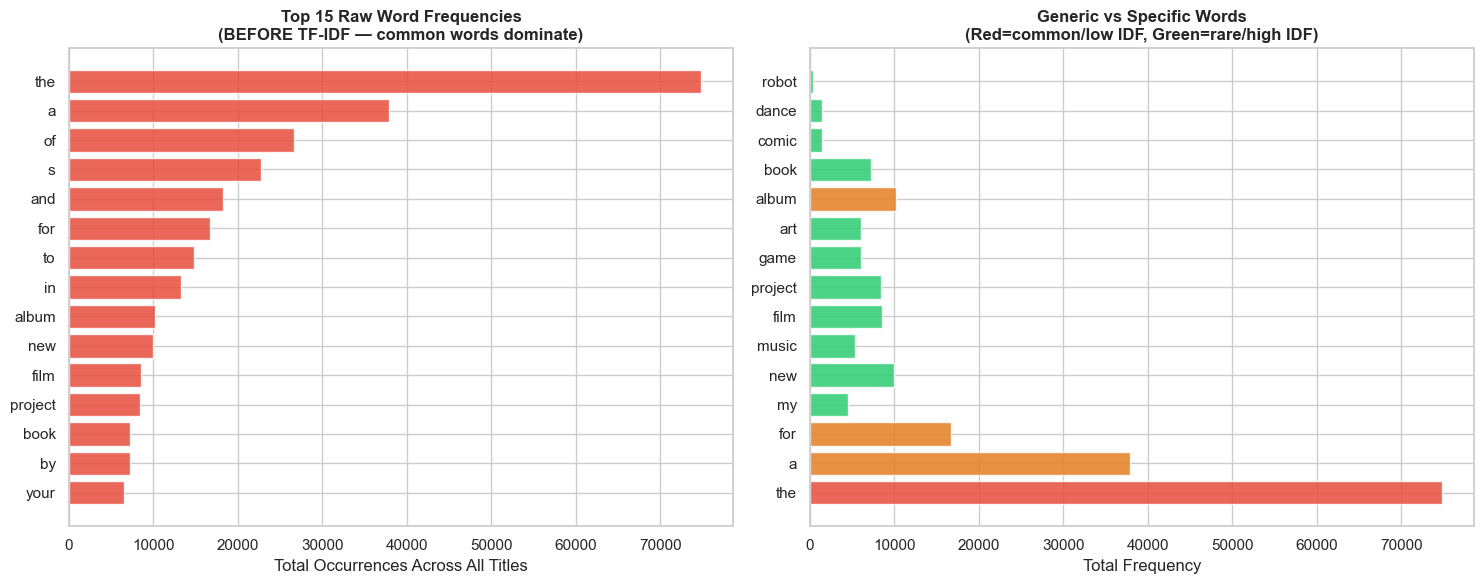

  ✅ Plot saved: plots/11_raw_word_frequency.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: raw word frequency
axes[0].barh(top_words_df['word'][:15][::-1],
             top_words_df['count'][:15][::-1],
             color='#e74c3c', edgecolor='white', alpha=0.85)
axes[0].set_title('Top 15 Raw Word Frequencies\n(BEFORE TF-IDF — common words dominate)',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Total Occurrences Across All Titles')

# Right: generic vs specific words colored by expected IDF
example_words  = ['the','a','for','my','new','music','film',
                  'project','game','art','album','book','comic','dance','robot']
example_counts = [word_counts.get(w, 0) for w in example_words]
col_ex = ['#e74c3c' if c > 50000 else '#e67e22' if c > 10000 else '#2ecc71'
          for c in example_counts]

axes[1].barh(range(len(example_words)), example_counts,
             color=col_ex, edgecolor='white', alpha=0.85)
axes[1].set_yticks(range(len(example_words)))
axes[1].set_yticklabels(example_words)
axes[1].set_title('Generic vs Specific Words\n(Red=common/low IDF, Green=rare/high IDF)',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Total Frequency')

plt.tight_layout()
plt.savefig(f"{CONFIG['plots_dir']}11_raw_word_frequency.png", dpi=150, bbox_inches='tight')
plt.show()
print("  ✅ Plot saved: plots/11_raw_word_frequency.png")


---
## Section 4 — Text Cleaning Pipeline

**What:** Clean raw campaign names before feeding to TF-IDF.  
**Why:** Raw names contain punctuation, numbers, mixed case, and symbols.  
These must be normalized so `"Film!"`, `"film"`, and `"FILM"` are treated as one token.

**Cleaning steps applied in order:**
1. **Lowercase** → `"Music"` and `"music"` become the same token
2. **Remove non-alpha characters** → `"B*tch!"` → `"btch"` (numbers, symbols, punctuation removed)
3. **Collapse whitespace** → `"  solar  coffee  "` → `"solar coffee"`
4. **Strip leading/trailing spaces**

We do NOT stem words (reducing "running" → "run") because `ngram_range=(1,2)` captures enough meaning without the added complexity.

**What to look for:** Special characters removed, case lowered, spacing normalized.


In [6]:
def clean_text(text):
    """
    Clean a single campaign name string.
    Steps: lowercase → remove non-alpha → collapse whitespace.
    Returns empty string for null/empty inputs.
    """
    if not isinstance(text, str) or text.strip() == '':
        return ''
    text = text.lower()                           # Step 1: lowercase
    text = re.sub(r'[^a-z\s]', ' ', text)        # Step 2: remove non-alpha
    text = re.sub(r'\s+', ' ', text).strip()      # Step 3: collapse spaces
    return text

# Show before/after on 10 real examples
print("  ── Before / After Cleaning (10 real examples) ──────────")
sample_names = df_train[CONFIG['text_col']].head(10).tolist()
for raw in sample_names:
    cleaned = clean_text(raw)
    print(f"  Raw    : {raw}")
    print(f"  Cleaned: {cleaned}")
    print()


  ── Before / After Cleaning (10 real examples) ──────────
  Raw    : LOAN DATA FINDER
  Cleaned: loan data finder

  Raw    : The Wedding Experience Documentary Film
  Cleaned: the wedding experience documentary film

  Raw    : Motu Matatahi Island
  Cleaned: motu matatahi island

  Raw    : One Love: Tia Marie Edmunds (An Interactive Experience)
  Cleaned: one love tia marie edmunds an interactive experience

  Raw    : Sibling Rivalry-An LGBT Love Triangle
  Cleaned: sibling rivalry an lgbt love triangle

  Raw    : Humbug - An Insect Learning Card Game
  Cleaned: humbug an insect learning card game

  Raw    : Bad Betty's Barbecue
  Cleaned: bad betty s barbecue

  Raw    : WormWatcher - Take Green Steps
  Cleaned: wormwatcher take green steps

  Raw    : LightBox: The light switch, re-invented.
  Cleaned: lightbox the light switch re invented

  Raw    : Project Start Up
  Cleaned: project start up



In [7]:
# Apply cleaning to train and test
train_names_clean = df_train[CONFIG['text_col']].apply(clean_text).tolist()
test_names_clean  = df_test[CONFIG['text_col']].apply(clean_text).tolist()

empty_train = sum(1 for t in train_names_clean if t == '')
empty_test  = sum(1 for t in test_names_clean  if t == '')

print(f"  Training names cleaned : {len(train_names_clean):,}")
print(f"  Test names cleaned     : {len(test_names_clean):,}")
print(f"  Empty after cleaning   : {empty_train} train / {empty_test} test")

avg_before = df_train[CONFIG['text_col']].str.len().mean()
avg_after  = pd.Series(train_names_clean).str.len().mean()
print(f"\n  Average name length before : {avg_before:.1f} chars")
print(f"  Average name length after  : {avg_after:.1f} chars")
print(f"\n  ✅ TF-IDF handles empty strings gracefully (zero weight row)")


  Training names cleaned : 265,266
  Test names cleaned     : 66,317
  Empty after cleaning   : 4 train / 0 test

  Average name length before : 34.2 chars
  Average name length after  : 32.7 chars

  ✅ TF-IDF handles empty strings gracefully (zero weight row)


---
## Section 5 — Fit TF-IDF on Training Data Only

**What:** Fit the TF-IDF vectorizer on training names **only**. Then transform both train and test using the fitted vocabulary — **no refitting on test data**.

**Why:** This is the core leakage prevention rule for text features.

If we fit on the full dataset:
- The vocabulary learns words from test campaigns
- The IDF scores are calculated using test documents
- The model sees test patterns before evaluation → inflated accuracy

**Correct workflow:**
```
tfidf.fit_transform(train_names)  → learns vocabulary + IDF weights, converts train to numbers
tfidf.transform(test_names)       → uses SAME vocabulary + IDF weights on test (no refitting)
```

Any word in test not in the train vocabulary is **silently ignored**. This is correct behavior.

**What to look for:** Matrix shape `[N × 2500]`. The 2500 cap prevents 50,000+ noisy features.


In [8]:
# Initialize vectorizer with CONFIG parameters
tfidf = TfidfVectorizer(
    max_features  = CONFIG['tfidf_max_features'],
    min_df        = CONFIG['tfidf_min_df'],
    max_df        = CONFIG['tfidf_max_df'],
    ngram_range   = CONFIG['tfidf_ngram_range'],
    sublinear_tf  = CONFIG['tfidf_sublinear_tf'],
    stop_words    = 'english',      # Remove stopwords (the, is, for, etc.)
    strip_accents = 'unicode',      # Normalize accented characters (café → cafe)
    analyzer      = 'word',
)

print("  Fitting TF-IDF on training data...")
print(f"  Training documents : {len(train_names_clean):,}")

# FIT on training data ONLY — this is non-negotiable
X_train_tfidf = tfidf.fit_transform(train_names_clean)   # fit + transform
X_test_tfidf  = tfidf.transform(test_names_clean)         # transform ONLY — no fit

print(f"\n  ✅ Training matrix : {X_train_tfidf.shape}")
print(f"     {X_train_tfidf.shape[0]:,} campaigns × {X_train_tfidf.shape[1]:,} TF-IDF features")
print(f"\n  ✅ Test matrix     : {X_test_tfidf.shape}")
print(f"     {X_test_tfidf.shape[0]:,} campaigns × {X_test_tfidf.shape[1]:,} TF-IDF features")

train_mem = X_train_tfidf.data.nbytes / (1024 * 1024)
test_mem  = X_test_tfidf.data.nbytes  / (1024 * 1024)
density   = X_train_tfidf.nnz / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1])
dense_mb  = X_train_tfidf.shape[0] * X_train_tfidf.shape[1] * 4 / (1024**2)

print(f"\n  Memory (sparse):")
print(f"    Train : {train_mem:.1f} MB   |  Dense equivalent : {dense_mb:.0f} MB")
print(f"    Test  : {test_mem:.1f} MB")
print(f"\n  Matrix density : {density:.3%}")
print(f"  (Only {density:.3%} of cells are non-zero — sparse format saves ~{dense_mb/train_mem:.0f}x memory)")


  Fitting TF-IDF on training data...
  Training documents : 265,266

  ✅ Training matrix : (265266, 2500)
     265,266 campaigns × 2,500 TF-IDF features

  ✅ Test matrix     : (66317, 2500)
     66,317 campaigns × 2,500 TF-IDF features

  Memory (sparse):
    Train : 5.4 MB   |  Dense equivalent : 2530 MB
    Test  : 1.3 MB

  Matrix density : 0.107%
  (Only 0.107% of cells are non-zero — sparse format saves ~468x memory)


---
## Section 6 — Inspect the TF-IDF Vocabulary

**What:** Examine the 2,500 words that made it into the vocabulary and their IDF scores.  
**Why:** This is your proof that TF-IDF is working correctly.
- Words with **HIGH IDF** are rare and specific → high discriminative power
- Words with **LOW IDF** are common (most removed by `stop_words='english'`)
- You should **NOT** see "the", "is", "for" in this vocabulary

**What to look for:** Specific, meaningful words with high IDF. No generic stopwords. Both unigrams (single words) and bigrams (two-word phrases).


In [9]:
vocab      = tfidf.get_feature_names_out()
idf_scores = tfidf.idf_

vocab_df           = pd.DataFrame({'token': vocab, 'idf_score': idf_scores})
vocab_df           = vocab_df.sort_values('idf_score', ascending=False)
vocab_df['is_bigram'] = vocab_df['token'].str.contains(' ')

unigrams = vocab_df[~vocab_df['is_bigram']]
bigrams  = vocab_df[vocab_df['is_bigram']]

print(f"  Total vocabulary size : {len(vocab):,} tokens")
print(f"  Unigrams (1-word)     : {len(unigrams):,}")
print(f"  Bigrams  (2-word)     : {len(bigrams):,}")

print(f"\n  ── Top 20 Unigrams by IDF Score (most rare/specific) ────────")
print(unigrams.head(20)[['token','idf_score']].to_string(index=False))

print(f"\n  ── Bottom 10 Unigrams by IDF Score (most common) ────────────")
print(unigrams.tail(10)[['token','idf_score']].to_string(index=False))

print(f"\n  ── Top 15 Bigrams by IDF Score ──────────────────────────────")
print(bigrams.head(15)[['token','idf_score']].to_string(index=False))

# Verify no stopwords leaked through
common_stops  = ['the','is','for','and','a','to']
leaked_stops  = [w for w in common_stops if w in set(vocab)]
if not leaked_stops:
    print(f"\n  ✅ No common stopwords in vocabulary — filtering worked correctly")
else:
    print(f"\n  ⚠️  Stopwords found in vocabulary: {leaked_stops}")


  Total vocabulary size : 2,500 tokens
  Unigrams (1-word)     : 2,314
  Bigrams  (2-word)     : 186

  ── Top 20 Unigrams by IDF Score (most rare/specific) ────────
     token  idf_score
      pong   9.268984
     towel   9.225812
       pit   9.211826
     ashes   9.198033
      reel   9.198033
resistance   9.198033
       mug   9.198033
       soy   9.184427
      loud   9.184427
underwater   9.184427
       pot   9.184427
   surface   9.184427
   reunion   9.184427
    liquid   9.184427
     linux   9.184427
     tiles   9.184427
    cowboy   9.171004
  graduate   9.171004
     doors   9.171004
 classroom   9.171004

  ── Bottom 10 Unigrams by IDF Score (most common) ────────────
  token  idf_score
  world   5.101180
   help   5.062976
  music   4.924034
    art   4.821156
   game   4.804937
   book   4.603466
project   4.457757
   film   4.445269
    new   4.303264
  album   4.256586

  ── Top 15 Bigrams by IDF Score ──────────────────────────────
              token  idf_score
ph

---
## Section 7 — Visualize Top TF-IDF Features

**What:** Plot the top features by IDF score, and compare average TF-IDF weights between successful and failed campaigns.  
**Why:** The IDF plot proves the vocabulary is meaningful. The success/failure comparison is a preview of what the model will learn — which words actually separate winners from losers. This analysis justifies using text features to a reviewer or interviewer.

**What to look for:** The success word plot should show specific, creative words. The failure word plot often shows generic terms ("help", "support", "need").


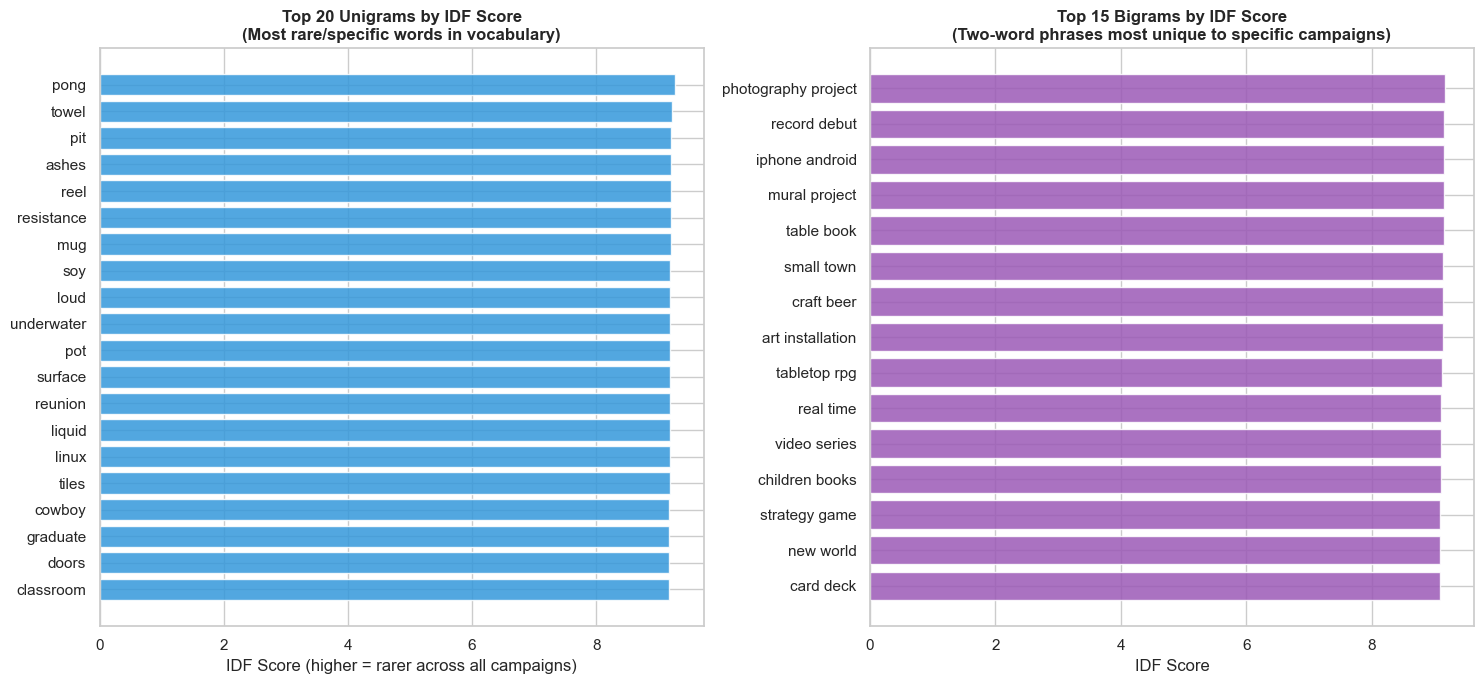

  ✅ Plot saved: plots/12_tfidf_vocabulary_idf_scores.png


In [10]:
# Plot 1: Top vocabulary by IDF score
top_unigrams_plot = vocab_df[~vocab_df['is_bigram']].head(20)
top_bigrams_plot  = bigrams.head(15)

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

axes[0].barh(top_unigrams_plot['token'][::-1],
             top_unigrams_plot['idf_score'][::-1],
             color='#3498db', edgecolor='white', alpha=0.85)
axes[0].set_title('Top 20 Unigrams by IDF Score\n(Most rare/specific words in vocabulary)',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('IDF Score (higher = rarer across all campaigns)')

axes[1].barh(top_bigrams_plot['token'][::-1],
             top_bigrams_plot['idf_score'][::-1],
             color='#9b59b6', edgecolor='white', alpha=0.85)
axes[1].set_title('Top 15 Bigrams by IDF Score\n(Two-word phrases most unique to specific campaigns)',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('IDF Score')

plt.tight_layout()
plt.savefig(f"{CONFIG['plots_dir']}12_tfidf_vocabulary_idf_scores.png", dpi=150, bbox_inches='tight')
plt.show()
print("  ✅ Plot saved: plots/12_tfidf_vocabulary_idf_scores.png")


  Computing average TF-IDF weights by outcome...
  (This takes ~10 seconds for 265,000 rows)

  ── Top 15 Words More Common in SUCCESSFUL Campaigns ────
      token     diff
      album 0.012179
       film 0.007496
        new 0.007222
      short 0.006242
      debut 0.005694
 short film 0.005516
         ep 0.005189
  new album 0.004095
     record 0.003655
debut album 0.003451
      issue 0.002500
         cd 0.002394
   festival 0.002361
     length 0.002331
    edition 0.002220

  ── Top 15 Words More Common in FAILED Campaigns ────────
   token      diff
     app -0.005236
clothing -0.003333
     com -0.003080
    life -0.002672
 apparel -0.002026
    food -0.002019
 fashion -0.001575
  mobile -0.001534
  social -0.001533
  online -0.001506
   truck -0.001225
   movie -0.001199
   dream -0.001185
      tv -0.001127
    real -0.001101


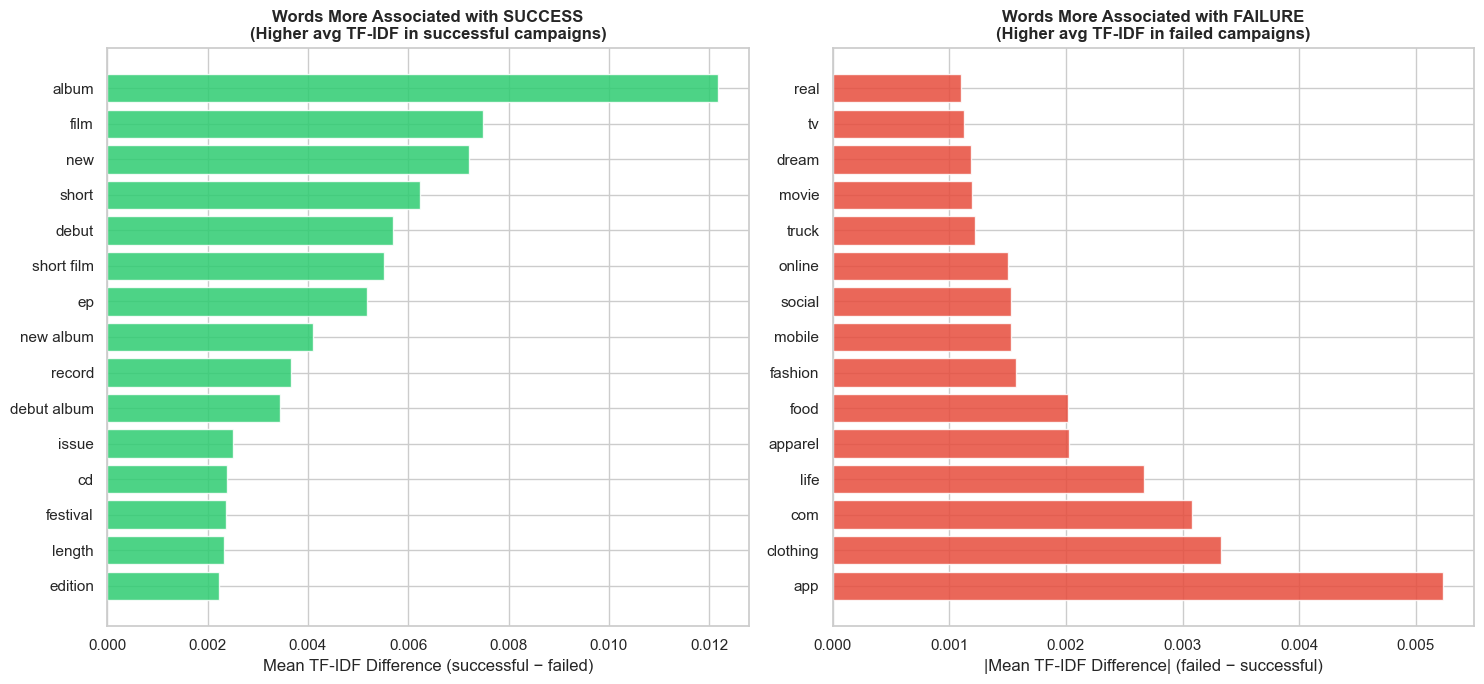

  ✅ Plot saved: plots/13_tfidf_success_vs_fail_words.png


In [11]:
# Plot 2: Words that separate successful from failed campaigns
print("  Computing average TF-IDF weights by outcome...")
print("  (This takes ~10 seconds for 265,000 rows)")

success_mask = (y_train == 1)
fail_mask    = (y_train == 0)

mean_success = np.asarray(X_train_tfidf[success_mask].mean(axis=0)).flatten()
mean_fail    = np.asarray(X_train_tfidf[fail_mask].mean(axis=0)).flatten()

diff    = mean_success - mean_fail
diff_df = pd.DataFrame({'token': vocab, 'diff': diff}).sort_values('diff', ascending=False)

top_success_words = diff_df.head(15)
top_fail_words    = diff_df.tail(15).sort_values('diff', ascending=True)

print("\n  ── Top 15 Words More Common in SUCCESSFUL Campaigns ────")
print(top_success_words[['token','diff']].to_string(index=False))
print("\n  ── Top 15 Words More Common in FAILED Campaigns ────────")
print(top_fail_words[['token','diff']].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

axes[0].barh(top_success_words['token'][::-1],
             top_success_words['diff'][::-1],
             color='#2ecc71', edgecolor='white', alpha=0.85)
axes[0].set_title('Words More Associated with SUCCESS\n(Higher avg TF-IDF in successful campaigns)',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Mean TF-IDF Difference (successful − failed)')

axes[1].barh(top_fail_words['token'],
             top_fail_words['diff'].abs(),
             color='#e74c3c', edgecolor='white', alpha=0.85)
axes[1].set_title('Words More Associated with FAILURE\n(Higher avg TF-IDF in failed campaigns)',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('|Mean TF-IDF Difference| (failed − successful)')

plt.tight_layout()
plt.savefig(f"{CONFIG['plots_dir']}13_tfidf_success_vs_fail_words.png", dpi=150, bbox_inches='tight')
plt.show()
print("  ✅ Plot saved: plots/13_tfidf_success_vs_fail_words.png")


---
## Section 8 — Sample Matrix Inspection

**What:** Look at actual rows of the TF-IDF matrix for specific campaigns.  
**Why:** Matrix shapes and density numbers are abstract. Looking at real rows confirms that specific words got their expected scores — that "music" in a music title has a non-zero weight.

**What to look for:** Non-zero weights for words that appear in the title, zero for words that don't, and sensible scores (more specific words score higher).


In [12]:
print("  ── Inspecting 5 sample training rows ────────────────────")
for i in range(5):
    raw_name    = df_train[CONFIG['text_col']].iloc[i]
    cleaned     = train_names_clean[i]
    row         = X_train_tfidf[i]
    nonzero_idx = row.nonzero()[1]
    top_tokens  = sorted(
        [(vocab[j], round(float(row[0, j]), 4)) for j in nonzero_idx],
        key=lambda x: -x[1]
    )[:5]

    print(f"\n  Row {i}:")
    print(f"    Original     : {raw_name}")
    print(f"    Cleaned      : {cleaned}")
    print(f"    Non-zero     : {len(nonzero_idx)} features out of {X_train_tfidf.shape[1]:,}")
    print(f"    Top 5 tokens : {top_tokens}")


  ── Inspecting 5 sample training rows ────────────────────

  Row 0:
    Original     : LOAN DATA FINDER
    Cleaned      : loan data finder
    Non-zero     : 1 features out of 2,500
    Top 5 tokens : [('data', 1.0)]

  Row 1:
    Original     : The Wedding Experience Documentary Film
    Cleaned      : the wedding experience documentary film
    Non-zero     : 5 features out of 2,500
    Top 5 tokens : [('wedding', 0.5717), ('documentary film', 0.4921), ('experience', 0.4581), ('documentary', 0.3645), ('film', 0.2973)]

  Row 2:
    Original     : Motu Matatahi Island
    Cleaned      : motu matatahi island
    Non-zero     : 1 features out of 2,500
    Top 5 tokens : [('island', 1.0)]

  Row 3:
    Original     : One Love: Tia Marie Edmunds (An Interactive Experience)
    Cleaned      : one love tia marie edmunds an interactive experience
    Non-zero     : 4 features out of 2,500
    Top 5 tokens : [('marie', 0.6225), ('interactive', 0.499), ('experience', 0.4682), ('love', 0.379

---
## Section 9 — Save All Artifacts

**What:** Serialize all outputs for use in later notebooks.  
**Why:** Every artifact saved here serves a specific downstream purpose:

| File | Purpose |
|---|---|
| `tfidf.pkl` | Fitted vectorizer — used in Notebook 03 and inference |
| `X_train_tfidf.npz` | Sparse TF-IDF matrix for training — used in Notebook 04 (fusion) |
| `X_test_tfidf.npz` | Sparse TF-IDF matrix for test — never used until final evaluation |
| `train_idx.npy` / `test_idx.npy` | Split indices — all notebooks load these to stay consistent |
| `y_train.npy` / `y_test.npy` | Binary labels for each split |

The `.npz` format is scipy's sparse matrix format — far more memory efficient than `.csv` for 95%+ zero data.

**What to look for:** All files created in `artifacts/`. Sizes shown confirm they are non-empty.


In [13]:
# Save fitted TF-IDF vectorizer
joblib.dump(tfidf,
            f"{CONFIG['artifacts_dir']}tfidf.pkl",
            compress=3)
print(f"  ✅ Saved → artifacts/tfidf.pkl")

# Save sparse matrices
scipy.sparse.save_npz(f"{CONFIG['artifacts_dir']}X_train_tfidf.npz", X_train_tfidf)
scipy.sparse.save_npz(f"{CONFIG['artifacts_dir']}X_test_tfidf.npz",  X_test_tfidf)
print(f"  ✅ Saved → artifacts/X_train_tfidf.npz  shape={X_train_tfidf.shape}")
print(f"  ✅ Saved → artifacts/X_test_tfidf.npz   shape={X_test_tfidf.shape}")

# Summary of all artifacts
print(f"\n  ── Artifacts Directory Contents ─────────────────────────")
for f in sorted(os.listdir(CONFIG['artifacts_dir'])):
    size_kb = os.path.getsize(f"{CONFIG['artifacts_dir']}{f}") / 1024
    print(f"    {f:<35} {size_kb:>8.1f} KB")


  ✅ Saved → artifacts/tfidf.pkl
  ✅ Saved → artifacts/X_train_tfidf.npz  shape=(265266, 2500)
  ✅ Saved → artifacts/X_test_tfidf.npz   shape=(66317, 2500)

  ── Artifacts Directory Contents ─────────────────────────
    X_test_tabular.npz                     941.8 KB
    X_test_tfidf.npz                      1593.5 KB
    X_train_tabular.npz                   3769.4 KB
    X_train_tfidf.npz                     6397.8 KB
    preprocessor.pkl                         3.0 KB
    tabular_feature_names.npy                6.0 KB
    test_idx.npy                           518.2 KB
    tfidf.pkl                               30.3 KB
    train_idx.npy                         2072.5 KB
    y_test.npy                             518.2 KB
    y_train.npy                           2072.5 KB


---
## Section 10 — Final Checklist

**What:** Reload every saved artifact from disk and verify correctness.  
**Why:** We write then reload — not just check in-memory objects. This proves the files on disk are valid and can be loaded by the next notebook cold (without re-running this one).

**What to look for:** All 8 checks must be ✅. Any ❌ means something broke and must be fixed before proceeding to Notebook 03.


In [14]:
# Reload from disk — not from in-memory objects
tfidf_loaded     = joblib.load(f"{CONFIG['artifacts_dir']}tfidf.pkl")
X_train_loaded   = scipy.sparse.load_npz(f"{CONFIG['artifacts_dir']}X_train_tfidf.npz")
X_test_loaded    = scipy.sparse.load_npz(f"{CONFIG['artifacts_dir']}X_test_tfidf.npz")
y_train_loaded   = np.load(f"{CONFIG['artifacts_dir']}y_train.npy")
y_test_loaded    = np.load(f"{CONFIG['artifacts_dir']}y_test.npy")
train_idx_loaded = np.load(f"{CONFIG['artifacts_dir']}train_idx.npy")
test_idx_loaded  = np.load(f"{CONFIG['artifacts_dir']}test_idx.npy")

print("=" * 60)
print("  FINAL CHECKLIST")
print("=" * 60)

# Check 1: Vocabulary size
vsize = len(tfidf_loaded.vocabulary_)
print("  " + ("✅" if vsize == CONFIG['tfidf_max_features'] else "❌") +
      f" Vocabulary size: {vsize:,} (expected {CONFIG['tfidf_max_features']:,})")

# Check 2: Train matrix shape
print("  " + ("✅" if X_train_loaded.shape[0] == len(train_idx_loaded) else "❌") +
      f" Train TF-IDF shape: {X_train_loaded.shape}")

# Check 3: Test matrix shape
print("  " + ("✅" if X_test_loaded.shape[0] == len(test_idx_loaded) else "❌") +
      f" Test  TF-IDF shape: {X_test_loaded.shape}")

# Check 4: No stopwords in vocabulary
vocab_loaded = tfidf_loaded.get_feature_names_out()
stop_leak    = [w for w in ['the','is','for','and','a','to'] if w in vocab_loaded]
print("  " + ("✅" if not stop_leak else "❌") +
      f" No stopwords in vocabulary" + (f" — leaked: {stop_leak}" if stop_leak else ""))

# Check 5: Labels match rows
print("  " + ("✅" if len(y_train_loaded) == X_train_loaded.shape[0] else "❌") +
      f" y_train length matches train rows: {len(y_train_loaded):,}")
print("  " + ("✅" if len(y_test_loaded) == X_test_loaded.shape[0] else "❌") +
      f" y_test  length matches test  rows: {len(y_test_loaded):,}")

# Check 6: Class balance preserved
print("  " + ("✅" if abs(y_train_loaded.mean() - y_test_loaded.mean()) < 0.005 else "❌") +
      f" Class balance: train={y_train_loaded.mean():.2%}  test={y_test_loaded.mean():.2%}")

# Check 7: Vectorizer works on new input
try:
    test_new = tfidf_loaded.transform(["music album recording studio project"])
    print(f"  ✅ Vectorizer transforms new input: shape={test_new.shape}  nnz={test_new.nnz}")
except Exception as e:
    print(f"  ❌ Vectorizer failed: {e}")

# Check 8: Split covers full dataset
total_split = len(train_idx_loaded) + len(test_idx_loaded)
print("  " + ("✅" if total_split == len(df) else "❌") +
      f" Split covers full dataset: {len(train_idx_loaded):,} + {len(test_idx_loaded):,} = {total_split:,}")


  FINAL CHECKLIST
  ✅ Vocabulary size: 2,500 (expected 2,500)
  ✅ Train TF-IDF shape: (265266, 2500)
  ✅ Test  TF-IDF shape: (66317, 2500)
  ✅ No stopwords in vocabulary
  ✅ y_train length matches train rows: 265,266
  ✅ y_test  length matches test  rows: 66,317
  ✅ Class balance: train=40.39%  test=40.39%
  ✅ Vectorizer transforms new input: shape=(1, 2500)  nnz=7
  ✅ Split covers full dataset: 265,266 + 66,317 = 331,583


In [15]:
print(f"""
============================================================
  NOTEBOOK 02 COMPLETE — SUMMARY
============================================================
  Input rows              : {len(df):,}
  Train rows              : {len(train_idx_loaded):,}  (80%)
  Test rows               : {len(test_idx_loaded):,}   (20%)
  TF-IDF vocabulary size  : {len(tfidf_loaded.vocabulary_):,} tokens
  Train matrix            : {X_train_loaded.shape}
  Test matrix             : {X_test_loaded.shape}
  Matrix density          : {X_train_loaded.nnz / (X_train_loaded.shape[0] * X_train_loaded.shape[1]):.3%}
  Plots generated         : 11_raw_word_frequency.png
                            12_tfidf_vocabulary_idf_scores.png
                            13_tfidf_success_vs_fail_words.png
============================================================
""")



  NOTEBOOK 02 COMPLETE — SUMMARY
  Input rows              : 331,583
  Train rows              : 265,266  (80%)
  Test rows               : 66,317   (20%)
  TF-IDF vocabulary size  : 2,500 tokens
  Train matrix            : (265266, 2500)
  Test matrix             : (66317, 2500)
  Matrix density          : 0.107%
  Plots generated         : 11_raw_word_frequency.png
                            12_tfidf_vocabulary_idf_scores.png
                            13_tfidf_success_vs_fail_words.png



---
## Section 11 — What Comes Next

Notebook 02 is complete. Here is what Notebook 03 builds on top of this:

| Notebook | What it does |
|---|---|
| `03_tabular_pipeline.ipynb` | Load same split indices, StandardScaler + OneHotEncoder via ColumnTransformer, save `preprocessor.pkl` + `X_train_tabular.npz` + `X_test_tabular.npz` |
| `04_fusion.ipynb` | `scipy.sparse.hstack(X_tfidf, X_tabular)` → single unified `[N × (2500 + n_tabular)]` matrix |
| `05_model_training.ipynb` | LogisticRegression + StratifiedKFold + PR-AUC evaluation |
| `06_evaluation.ipynb` | Feature coefficients, PR curves, threshold tuning |
| `07_inference.ipynb` | `predict_campaign(input_dict)` — the product |

**Rule for Notebook 03:** Load `artifacts/train_idx.npy` and `artifacts/test_idx.npy` — **never create a new split.**
